In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection


### Objective
0. Run after neur3.ipynb
1. Visualize trial contrasted PSTH for example patient
2. Encoding analyses across patients

epoch & contrast data

In [2]:
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']
epoch, contrast = 'stim', 'boundary_context'
normalize = False

per epoch, get trial ids for contrasts in variable of interest, and assign labels

In [ ]:
def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    ''' split pre-loaded epoch arrays by contrast,
    return list of trial indices for each contrast group and their labels '''

    cont_trials, cont_labels = [], []

    if contrast == 'shape_class': # relative shape
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
                
    elif contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    elif contrast == 'ambiguity':
        cont_trials.append(psychopy_df[~psychopy_df['uncertainty']].index)
        cont_trials.append(psychopy_df[psychopy_df['uncertainty']].index)
        cont_labels += ['certain', 'uncertain']
    elif contrast == 'resp_dir':
        cont_trials.append(psychopy_df[psychopy_df['chosen_pos'] > psychopy_df['div_pos']].index)
        cont_trials.append(psychopy_df[psychopy_df['chosen_pos'] < psychopy_df['div_pos']].index)
        cont_labels += ['right', 'left']
    elif contrast == 'normed_RT':
        median_rt = psychopy_df['normed_RT'].median()
        cont_trials.append(psychopy_df[psychopy_df['normed_RT'] <= median_rt].index)
        cont_trials.append(psychopy_df[psychopy_df['normed_RT'] > median_rt].index)
        cont_labels += ['fast', 'slow']
    elif contrast == 'outcome': # feedback
        for val, label in zip([3, 1, -1, -3], ['3 coins', '1 coin', '-1 coin', '-3 coins']):
            cont_trials.append(psychopy_df[psychopy_df['outcome'] == val].index)
            cont_labels.append(label)
    elif contrast == 'binarized_context':
        cont_trials.append(psychopy_df[psychopy_df['condition'] == 'baseline'].index)
        cont_trials.append(psychopy_df[psychopy_df['condition'] != 'baseline'].index)
        cont_labels += ['base', 'comp']
    else:
        raise ValueError(f'Invalid contrast: {contrast}')

    if verbose:
        print(f'contrast: {contrast}')
        print(f'num_trials per group should be ~240/num_contrasts')
    return cont_trials, cont_labels

loading patient data

In [15]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs.csv')
# reorder columns to put trial_key first
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]

# make a list of patients with any data
patients = psychopy_df['subj'].unique().tolist()
print(patients)

# drop patients without neural data
for patient in [1.1, 1.11, 1.111, 1.1111, 9, 11]: patients.remove(patient)
print(f'neural patients: {patients}\n')

psychopy_df

[1.1, 1.11, 1.111, 1.1111, 9.0, 11.0, 12.0, 18.0, 21.0, 22.0]
neural patients: [12.0, 18.0, 21.0, 22.0]



,trial_key,thisN,thisTrialN,thisRepN,blockN,run,condition,stim_file_pos,true_stim,noise_pos,...,stim_boundary_aligned,resp_boundary_aligned,rank_stim,rank_resp,baseline_dur,stim_dur,delay_dur,task_dur,anticipation_dur,feedback_dur
0,161.0,39.0,39.0,0.0,5.0,2.0,curv_comp,0.1,-0.38,1.0,...,-0.18,-0.060,4.5,3.0,0.991922,1.068953,1.342020,2.243022,0.259576,1.150575
1,85.0,6.0,6.0,0.0,3.0,1.0,flat_comp,1.5,-0.10,1.0,...,-0.30,-0.016,10.5,28.5,0.941895,1.111298,1.391949,3.656820,0.263271,1.009689
2,96.0,5.0,5.0,0.0,3.0,1.0,flat_comp,2.7,0.14,1.0,...,-0.06,-0.036,34.5,15.0,0.942002,1.256935,1.491991,2.124720,0.249153,1.025546
3,86.0,4.0,4.0,0.0,3.0,1.0,flat_comp,1.7,-0.06,3.0,...,-0.26,-0.060,14.5,8.0,0.891919,1.153779,1.341997,1.630550,0.280812,1.017496
4,94.0,3.0,3.0,0.0,3.0,1.0,flat_comp,2.5,0.10,3.0,...,-0.10,-0.044,30.5,10.5,0.891990,1.408124,1.491905,3.316893,0.305029,1.005972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,149.0,34.0,34.0,0.0,4.0,2.0,baseline,2.9,0.18,1.0,...,0.18,-0.120,58.5,42.5,0.935376,0.983497,1.335166,2.447776,0.248388,0.983547
2396,137.0,33.0,33.0,0.0,4.0,2.0,baseline,1.7,-0.06,3.0,...,-0.06,-0.152,34.5,39.0,0.985082,0.983486,1.483713,1.949264,0.248343,0.983538
2397,123.0,32.0,32.0,0.0,4.0,2.0,baseline,0.3,-0.34,3.0,...,-0.34,-0.364,6.5,9.0,0.983819,0.983482,1.383988,1.048629,0.249313,0.983556
2398,179.0,4.0,4.0,0.0,5.0,2.0,curv_comp,0.9,-0.22,3.0,...,-0.02,-0.056,36.5,46.5,0.984662,0.983487,1.385386,2.747314,0.248680,0.983559


per patient, load psychopy_df (for trial ids), neuron_df (for region labels), and epoch spike/FR/bin arrays 

In [16]:
def get_pt_metadata(patient, verbose=True):
    ''' load patient-level dataframes: psychopy_df for trial info, neur_df for neuron info '''

    pt_data_dir = f'../../results/2025{int(patient)}/records/processed_data'

    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs = len(pt_neur_df)

    if verbose:
        print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    ''' load spike/FR/bin arrays for a single patient + epoch '''

    pt_data_dir = f'../../results/2025{int(patient)}/records/processed_data'

    pt_epoch_spikes = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs    = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins   = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)

    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
        print(f'bins (bins, ): {pt_epoch_bins.shape}\n')

    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins

### 1. contrasted rasters + PSTHs for single patient

choose patient, epoch, contrast, and normalization params

In [17]:
# patient data
patient = 18
pt_psychopy_df, pt_neur_df, pt_num_neurs = get_pt_metadata(patient)

# epoch data
epoch = 'stim'
pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins = get_pt_epoch_spike_data(patient, epoch)

# contrast data
contrast = 'boundary_context'
cont_trials, cont_labels = get_contrast_in_epoch(pt_psychopy_df, contrast)

# normalization data
normalize = True
if normalize:
    _, _, baseline_FRs, _ = get_pt_epoch_spike_data(patient, 'baseline')
    normed_FRs = pt_epoch_FRs - baseline_FRs.mean(axis=(0,2), keepdims=True)
    yaxis_lab = 'norm. '
    print('\nnormalizing')
else:
    normed_FRs, yaxis_lab = pt_epoch_FRs.copy(), ''
    print('\nnot normalizing')

patient=18 num_trials=240 num_neurons=13

patient=18, epoch=stim
spikes (trials, neurons): (240, 13)
FRs (trials, neurons, bins): (240, 13, 125)
bins (bins, ): (125,)

contrast: boundary_context
num_trials per group should be ~240/num_contrasts
patient=18, epoch=baseline
spikes (trials, neurons): (240, 13)
FRs (trials, neurons, bins): (240, 13, 100)
bins (bins, ): (100,)


normalizing


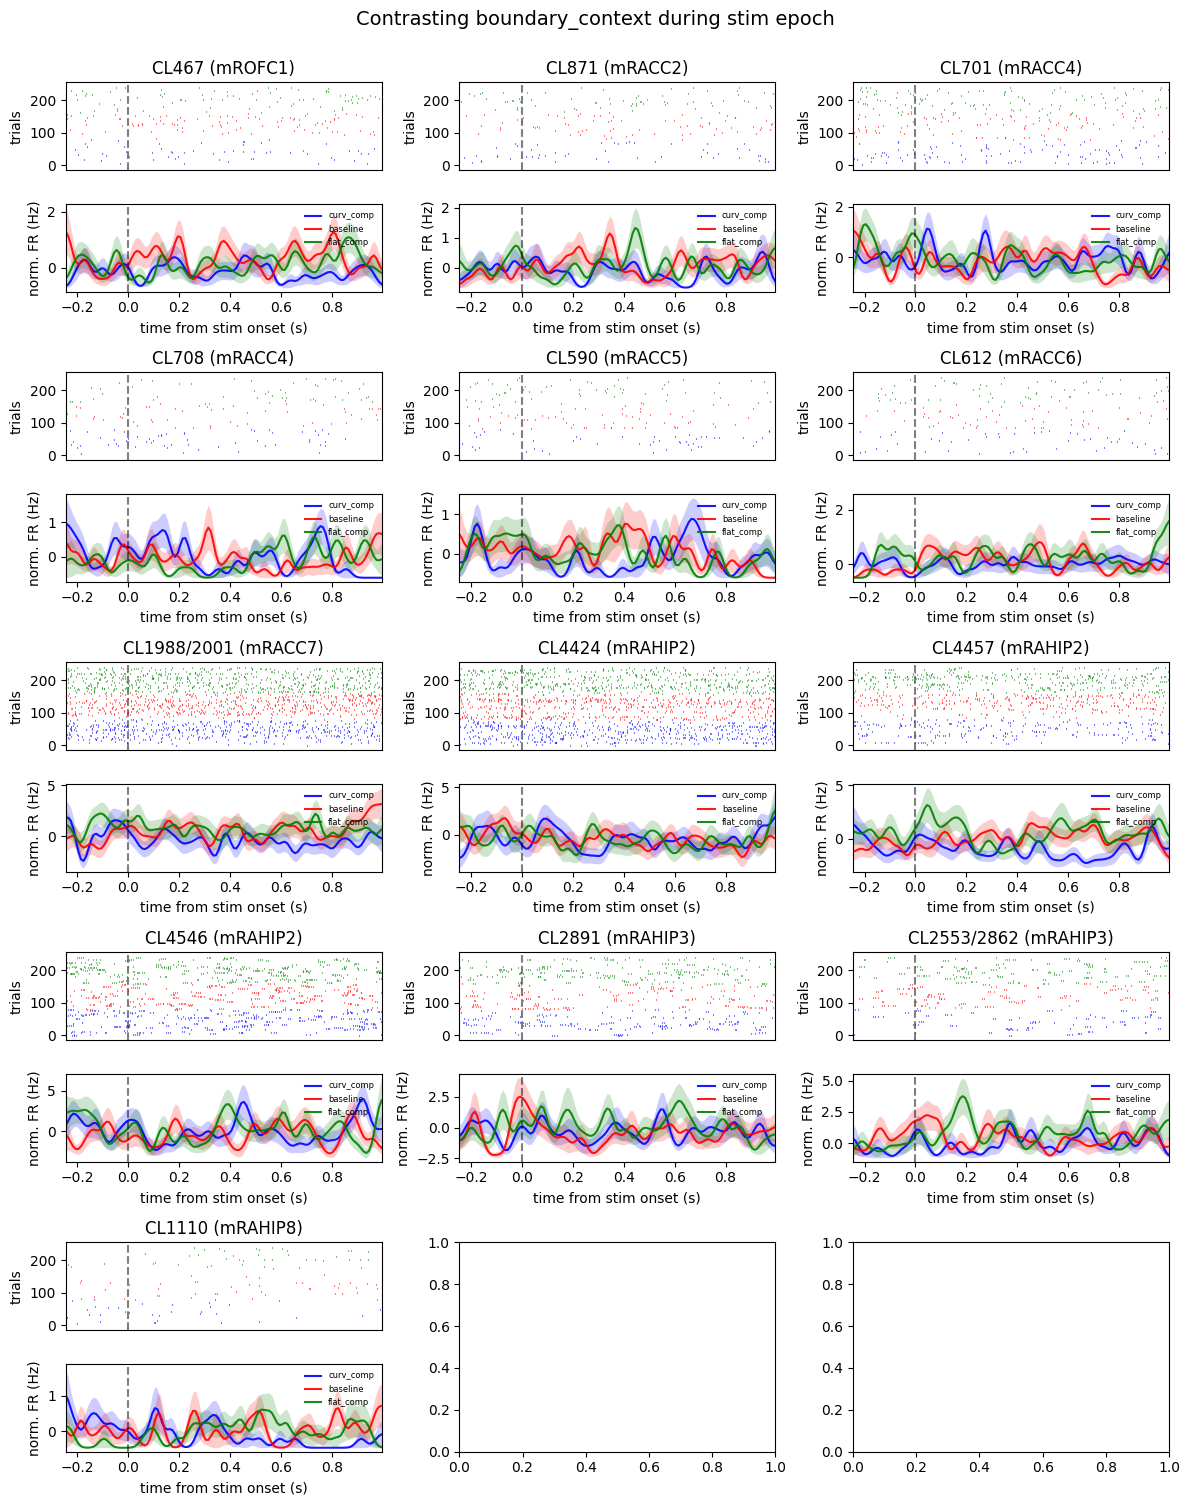

In [18]:
# plot
n_cols = 3
n_rows = int(np.ceil(pt_num_neurs / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axs, ax_idx = axs.flatten(), 0
colors = ['b', 'r', 'g', 'k'] # contrast colors

for neur_id in range(pt_num_neurs):
    if ax_idx >= len(axs): break

    # reconfigure each neur's subplot into 2 rows: raster on top, psth on bottom
    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()

    # create new subplotspec for raster and psth
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(cont_labels)):
        raster_trial_list.extend(list(pt_epoch_spikes[cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list, linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"CL{pt_neur_df['unitID'].iloc[neur_id]} ({pt_neur_df['region'].iloc[neur_id]})", ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(cont_labels)):
        cont_data = normed_FRs[cont_trials[idx], neur_id, :]
        mu = cont_data.mean(axis=0)
        sderr = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                 if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(pt_epoch_bins, mu, color=colors[idx], alpha=0.9, label=cont_labels[idx])
        ax_psth.fill_between(pt_epoch_bins, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(pt_epoch_bins[0], pt_epoch_bins[-1]), ylabel=f'{yaxis_lab}FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

    ax_idx += 1

plt.suptitle(f'Contrasting {contrast} during {epoch} epoch', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### 2. encoding across patients

In [24]:
epoch, contrast, alpha = 'stim', 'boundary_context', 0.05

# loop patients: collect raw H stats + p-values
pt_neur_dfs = []
for patient in patients:

    # get patient, epoch, and contrast data
    pt_psychopy_df, pt_neur_df, pt_num_neurs = get_pt_metadata(patient, verbose=False)
    _, pt_epoch_num_spikes, _, _ = get_pt_epoch_spike_data(patient, epoch, verbose=False)
    cont_trials, cont_labels = get_contrast_in_epoch(pt_psychopy_df, contrast, verbose=False)

    # kuskal-wallis
    H_stats, pvals = np.full(pt_num_neurs, np.nan), np.full(pt_num_neurs, np.nan)
    for neur in range(pt_num_neurs):
        contrast_spike_counts = [pt_epoch_num_spikes[cont_trials[i], neur] for i in range(len(cont_labels))]
        H_stats[neur], pvals[neur] = stats.kruskal(*contrast_spike_counts)

    # append — stamp neur_idx here so it's guaranteed correct
    pt_neur_df['H'], pt_neur_df['pval'] = H_stats, pvals
    pt_neur_df['pop_neur_idx'] = np.arange(pt_num_neurs)
    pt_neur_dfs.append(pt_neur_df)

all_neurs_df = pd.concat(pt_neur_dfs, ignore_index=True)

# pooled FDR correction across all neurons
all_neurs_df['pval_fdr'] = np.nan
all_neurs_df['significant'], all_neurs_df['pval_fdr'] = fdrcorrection(all_neurs_df['pval'], alpha=alpha)

n_sig = all_neurs_df['significant'].sum()
n_tested = all_neurs_df['pval'].notna().sum()
print(f'epoch={epoch} | contrast={contrast} | alpha={alpha}')
print(f'total neurons: {len(all_neurs_df)}')
print(f'significant (pooled FDR q<{alpha}): {n_sig} / {n_tested} tested')
# print sigfic neurs per patient
print('\n#sigfic neurs by patient')
print(all_neurs_df.groupby('patient')['significant'].sum())

all_neurs_df[all_neurs_df['significant']]


epoch=stim | contrast=boundary_context | alpha=0.05
total neurons: 57
significant (pooled FDR q<0.05): 3 / 57 tested

#sigfic neurs by patient
patient
12    2
18    0
21    1
22    0
Name: significant, dtype: int64


,patient,chanID,unitID,spikes,num_spikes,FR,keeps,mergers,region,x,y,z,H,pval,pop_neur_idx,pval_fdr,significant
5,12,102,2477,"[18.131033333333335, 18.393666666666668, 18.54...",10843,6.764394,1.0,NaN,mLOFC6,-2.511159,42.570655,-15.682235,15.587150,0.000412,5,0.011753,True
13,12,111,1972,"[877.2783000000002, 877.2957333333334, 885.844...",2072,2.785092,1.0,NaN,mLACC7,-1.311382,35.375616,18.278047,20.369994,0.000038,13,0.002151,True
49,21,224,3117,"[967.7238666666667, 1001.8905666666667, 1003.9...",1583,2.006072,1.0,NaN,224,NaN,NaN,NaN,11.941282,0.002553,13,0.048499,True


### significant neurons across patients

Plotting 3 significant neurons across 2 patients


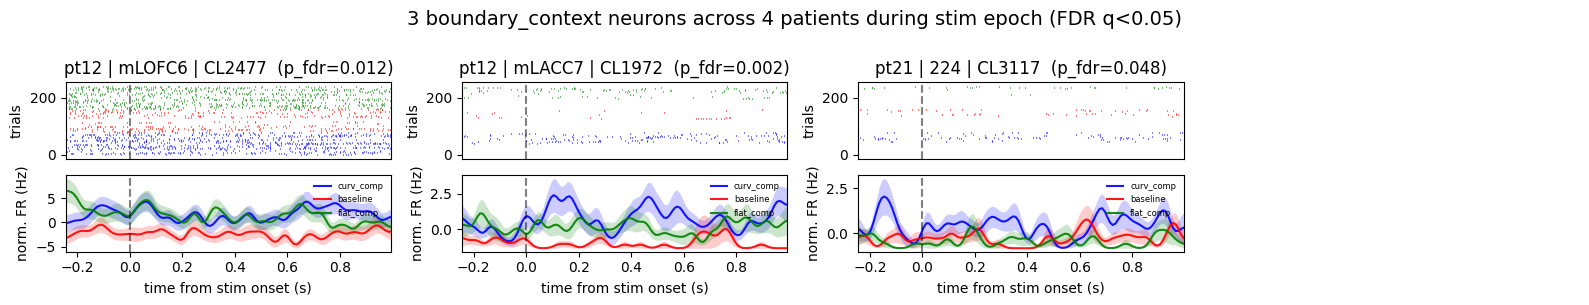

In [25]:
# Raster + PSTH for significant neurons across all patients
# Uses epoch, contrast, alpha, and all_neurs_df from the encoding cell above

colors = ['b', 'r', 'g', 'k']

sig_df = all_neurs_df[all_neurs_df['significant']].copy().reset_index(drop=True)
print(f'Plotting {len(sig_df)} significant neurons across {sig_df["patient"].nunique()} patients')

# load per-patient data, normalizing FRs by trial-averaged baseline
_cache = {}
for pt in patients:
    _pt_psychopy_df, _, _ = get_pt_metadata(pt, verbose=False)
    _pt_spikes, _, _pt_FRs, _pt_bins = get_pt_epoch_spike_data(pt, epoch, verbose=False)
    _, _, _pt_base_FRs, _ = get_pt_epoch_spike_data(pt, 'baseline', verbose=False)
    _pt_normed_FRs = _pt_FRs - _pt_base_FRs.mean(axis=(0, 2), keepdims=True)
    _pt_cont_trials, _pt_cont_labels = get_contrast_in_epoch(_pt_psychopy_df, contrast, verbose=False)
    _cache[pt] = (_pt_spikes, _pt_normed_FRs, _pt_bins, _pt_cont_trials, _pt_cont_labels)

n_cols = 4
n_rows = max(1, int(np.ceil(len(sig_df) / n_cols)))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axs = np.array(axs).flatten()

for ax_idx, (_, row) in enumerate(sig_df.iterrows()):
    pt      = row['patient']
    neur_id = int(row['pop_neur_idx'])
    pt_spikes, pt_normed_FRs, pt_bins, pt_cont_trials, pt_cont_labels = _cache[pt]

    ss = axs[ax_idx].get_subplotspec()
    axs[ax_idx].remove()
    gs = ss.subgridspec(2, 1, height_ratios=[1, 1])
    ax_raster = fig.add_subplot(gs[0])
    ax_psth   = fig.add_subplot(gs[1], sharex=ax_raster)

    # raster
    raster_trial_list, color_trial_list = [], []
    for idx in range(len(pt_cont_labels)):
        raster_trial_list.extend(list(pt_spikes[pt_cont_trials[idx], neur_id]))
        color_trial_list.extend([colors[idx]] * len(pt_cont_trials[idx]))

    ax_raster.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_raster.eventplot(raster_trial_list, orientation='horizontal', colors=color_trial_list,
                        linewidths=0.8, linelengths=3.0)
    ax_raster.set(title=f"pt{pt} | {row['region']} | CL{row['unitID']}  (p_fdr={row['pval_fdr']:.3f})",
                  ylabel='trials')
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # psth
    for idx in range(len(pt_cont_labels)):
        cont_data = pt_normed_FRs[pt_cont_trials[idx], neur_id, :]
        mu     = cont_data.mean(axis=0)
        sderr  = (cont_data.std(axis=0, ddof=1) / np.sqrt(cont_data.shape[0])
                  if cont_data.shape[0] > 1 else np.zeros_like(mu))
        ax_psth.plot(pt_bins, mu, color=colors[idx], alpha=0.9, label=pt_cont_labels[idx])
        ax_psth.fill_between(pt_bins, mu - sderr, mu + sderr, color=colors[idx], alpha=0.2, linewidth=0)

    ax_psth.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_psth.set(xlim=(pt_bins[0], pt_bins[-1]),
                ylabel='norm. FR (Hz)', xlabel=f'time from {epoch} onset (s)')
    ax_psth.legend(loc='upper right', fontsize=6, frameon=False)

# hide unused axes
for ax_idx in range(len(sig_df), len(axs)):
    axs[ax_idx].axis('off')

plt.suptitle(f'{len(sig_df)} {contrast} neurons across {len(patients)} patients during {epoch} epoch (FDR q<{alpha})', y=1.0, fontsize=14)
plt.tight_layout()
plt.show()